In [16]:
import os, sys, pickle
from importlib import reload
%pylab inline
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 2.5)
from label_axes.label_axes import label_axes
def inspect(obj):
    return [f for f in dir(obj) if not f.startswith("_")]

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/camp/home/tootoos/working/tootoos/conda-envs/numpyro-env/lib/python3.10/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['split', 'inspect']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [17]:
from glom_io_transform import paths

# Figure: Explain Models

In [24]:
from glom_io_transform.analysis.compute import explain_models as compute_explain_models
reload(compute_explain_models)
explain_models_data = compute_explain_models.Data().compute(seeds=[0,1,2])

COMPUTING explain_models.Data.


KeyboardInterrupt: 

PLOTTING FIGURE ExplainModels
Geometry schematic not found at /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/art/diag_geometry.png; leaving panel blank.
PLOTTING PANELS DiagPhase
PLOTTING PANELS DiagApprox
PLOTTING PANELS FreeConn
PLOTTING PANELS FreeConnModes
PLOTTING PANELS FreeConnModesHist


/tmp/ipykernel_232292/1666317817.py:8: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  tight_layout(w_pad=0.5)#h_pad=0, w_pad=0.5)


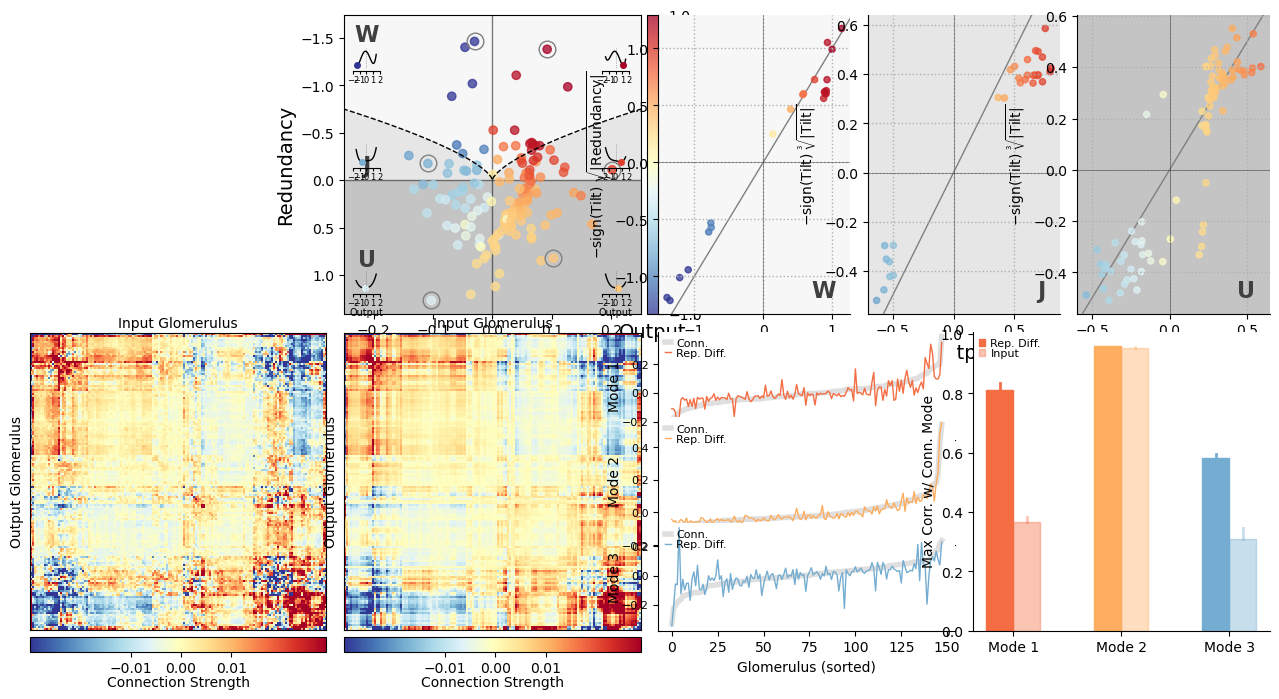

In [3]:
from glom_io_transform.analysis.figures import explain_models as fig_explain_models
reload(fig_explain_models)
from glom_io_transform.analysis.figures import figures as fig_figures
reload(fig_figures)
from glom_io_transform.analysis.figures.figures import reduce_vertical_gaps
fig = figure(figsize=(16, 8)); #title("HellO")
ax = fig_explain_models.Main.plot(explain_models_data)
tight_layout(w_pad=0.5)#h_pad=0, w_pad=0.5)
ax_modes = ax["modes"]
ax_hist = ax["hist"]
reduce_vertical_gaps(ax_modes, 0.1)

# Figure: Show Models

In [103]:
from glom_io_transform.analysis.compute import show_models as compute_show_models
reload(compute_show_models)
show_models_data = compute_show_models.Da   ta().compute()

COMPUTING show_models.Data.
Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:13<00:00, 37.81it/s]


Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=odours/mode=random/n_od_train=max/loaded_models.p.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:14<00:00, 34.72it/s]


Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=odours/mode=inclass/n_od_train=max/loaded_models.p.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:15<00:00, 33.28it/s]


Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=odours/mode=outclass/n_od_train=max/loaded_models.p.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [02:46<00:00, 17.97it/s]


Wrote /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results.pkl.
Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.


PLOTTING FIGURE ShowModels
PLOTTING PANELS Schem
PLOTTING PANELS Schem
Saved figure to /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/figs/fig_show_models.pdf


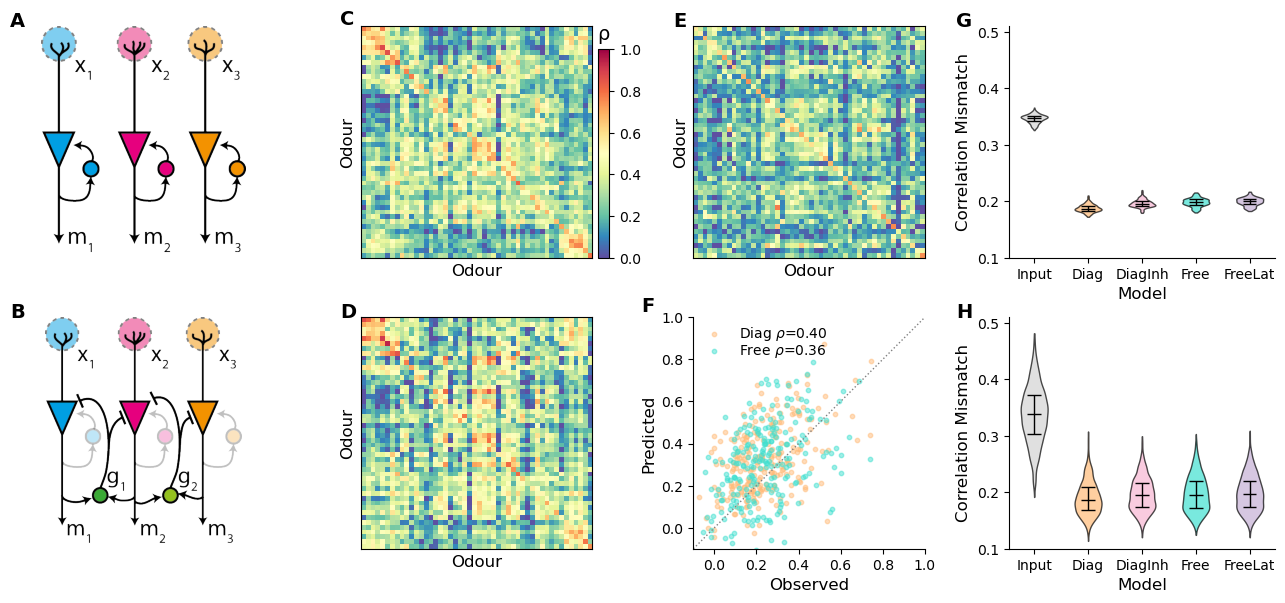

In [108]:
from glom_io_transform.analysis.figures import show_models as fig_show_models; reload(fig_show_models)
from glom_io_transform import paths
fig = figure(figsize=(13, 6)); #title("HellO")
ax = fig_show_models.Main.plot(show_models_data)#, free_corr_energy=free_data.corr_energy)
tight_layout(w_pad=0.5)
label_axes([ax[k] for k in ax], "ABCDEFGH", fontsize=14, fontweight="bold")
fig_file = f"{paths.proj_path}/figs/fig_show_models.pdf"
savefig(fig_file, bbox_inches="tight", dpi=600)
print(f"Saved figure to {fig_file}")

# Generalization Supplementaries

In [40]:
from glom_io_transform.model_fitting import results, split; reload(results); reload(split)
from glom_io_transform.analysis import compute; reload(compute)
from glom_io_transform.analysis.compute import generalization as compute_generalization
reload(compute_generalization)

n_od_train = "18_var_output"
loss = "cov"
which_models = ["Diag", "Free"]
if loss == "resp":
    which_models += ["FreePSD", "FreeSym"]
generalization_data = compute_generalization.Data().compute(compute_df=True, 
                                                            loss=loss, 
                                                            matched=True,
                                                            which_models=which_models,
                                                            splits=[("trials", "random", n_od_train),
                                                                    #("odours", "random", "max")
                                                                    ],
                                                        check_staleness=True,

                                                            )

COMPUTING generalization.Data.
Computing generalization results for 1 splits and 2 models.
Using /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results_matched_n_od_train=18_var_output.pkl as the cache file.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:03<00:00, 140.14it/s]

Wrote /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results_matched_n_od_train=18_var_output.pkl.


### Plot Generalization Violinplots

PLOTTING FIGURE Generalization (prefix='cov')
  cov  trials random   (n = 50)
    Diag<Input             2-sided  median diff -0.2579 [-0.2686, -0.2375]  p = 1.78e-15  ***
    Free<Input             2-sided  median diff -0.2675 [-0.2871, -0.2479]  p = 1.78e-15  ***
    Free<Diag              2-sided  median diff -0.01224 [-0.01976, -0.004584]  p = 4.03e-06  ***
Saved figure to /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/figs/supp_generalization_results_loss=resp_matched_n_od_train=18_rand_1__cov.pdf
PLOTTING FIGURE Generalization (prefix='corr')
  corr  trials random   (n = 50)
    Input<Diag             2-sided  median diff -0.0837 [-0.09929, -0.06588]  p = 1.78e-15  ***
    Free<Input             2-sided  median diff -0.02803 [-0.04352, -0.01481]  p = 3.4e-11  ***
    Free<Diag              2-sided  median diff -0.1124 [-0.1283, -0.09033]  p = 1.78e-15  ***
Saved figure to /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_

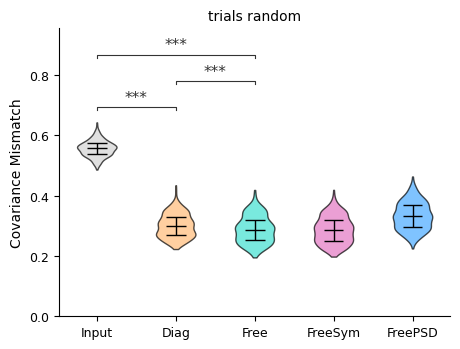

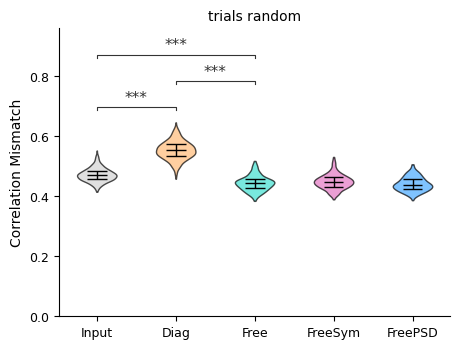

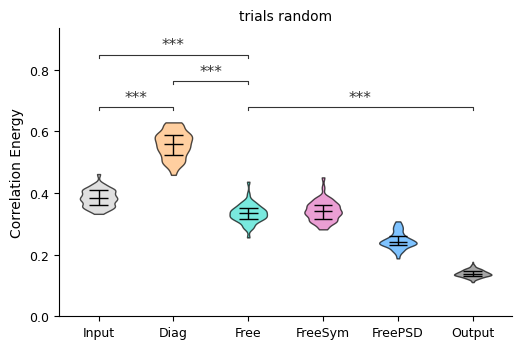

In [19]:
from glom_io_transform.analysis.figures import generalization as fig_generalization; reload(fig_generalization)
figname_stem = os.path.basename(generalization_data.cache_file).replace(".pkl", "")
for metric in ["cov", "corr", "corr_en"]:
    fig_generalization.Supp.plot(generalization_data, prefix=metric, figsize=None, 
                                 comparisons=["Diag:Input", "Free:Input", "Free:Diag"] + (["Output:Free"] if metric == "corr_en" else []))
    tight_layout(w_pad=0.5, h_pad=0.5)
    fig_file = os.path.join(paths.proj_path, f"figs/supp_{figname_stem}__{metric}.pdf")
    savefig(fig_file, bbox_inches="tight", dpi=600)
    print(f"Saved figure to {fig_file}")

# Matched ROIs Analysis

In [55]:
from glom_io_transform import logs; logs.quiet()
from glom_io_transform.model_fitting import driver; reload(driver)
from glom_io_transform.analysis import compute; reload(compute)
from glom_io_transform.analysis.compute import matched_rois as compute_matched_rois; reload(compute_matched_rois)
from glom_io_transform.analysis.figures import figures as fig_figures; reload(fig_figures)
from glom_io_transform.analysis.figures import matched_rois as fig_matched_rois; reload(fig_matched_rois)

<module 'glom_io_transform.analysis.figures.matched_rois' from '/nemo/lab/schaefera/working/tootoos/git/glom-io-transform-release/glom_io_transform/analysis/figures/matched_rois.py'>

## Compute Matched ROI Data

In [56]:
matched_rois_data = compute_matched_rois.Data().compute(n_od_train=n_od_train)

COMPUTING matched_rois.Data.
Loaded generalization results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results_matched_n_od_train=18_var_output.pkl.
Loaded generalization results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results_loss=resp_matched_n_od_train=18_var_output.pkl.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:13<00:00, 36.83it/s]


  refitting Diag at loss=resp ...
Regularizing z**1 - 1
bounds (-inf, inf)
Running minimization with 22 initial conditions.
Started at: 2026-08-24 06:50:41
RESP_LOSS at regularization target: 8.41603854e-02
Running minimization with initial condition 1/22.
RUNNING MINIMIZATION using method='L-BFGS-B'.
Started at: 2026-08-24 06:50:41
Gradient check passed with error 2.1781672914066622e-17
RESP_LOSS at initial guess: 0.26087515936506617
[   1] f = 1.99274924e-01 RESP_LOSS = 1.99274852e-01 REG = 7.13967418e-08 |g|inf = 3.905e-02
[   2] f = 8.78589078e-02 RESP_LOSS = 8.78588555e-02 REG = 5.23265004e-08 |g|inf = 1.077e-02
[   3] f = 6.35905151e-02 RESP_LOSS = 6.35904713e-02 REG = 4.37657084e-08 |g|inf = 1.110e-02
[   4] f = 3.68122998e-02 RESP_LOSS = 3.68122709e-02 REG = 2.89307672e-08 |g|inf = 5.253e-03
[   5] f = 3.07649167e-02 RESP_LOSS = 3.07648944e-02 REG = 2.22788147e-08 |g|inf = 2.086e-03
[   6] f = 2.88646148e-02 RESP_LOSS = 2.88645962e-02 REG = 1.85778370e-08 |g|inf = 8.587e-04
[  

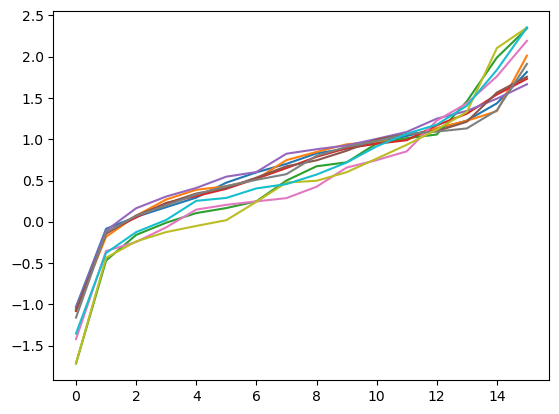

In [53]:
for i in range(10):
    Z_sym = matched_rois_data.Z_vals[i]["Z_sym"]
    ee,vv = np.linalg.eigh(Z_sym)
    plot(ee)

## Plot Main Panel

PLOTTING FIGURE matched_rois


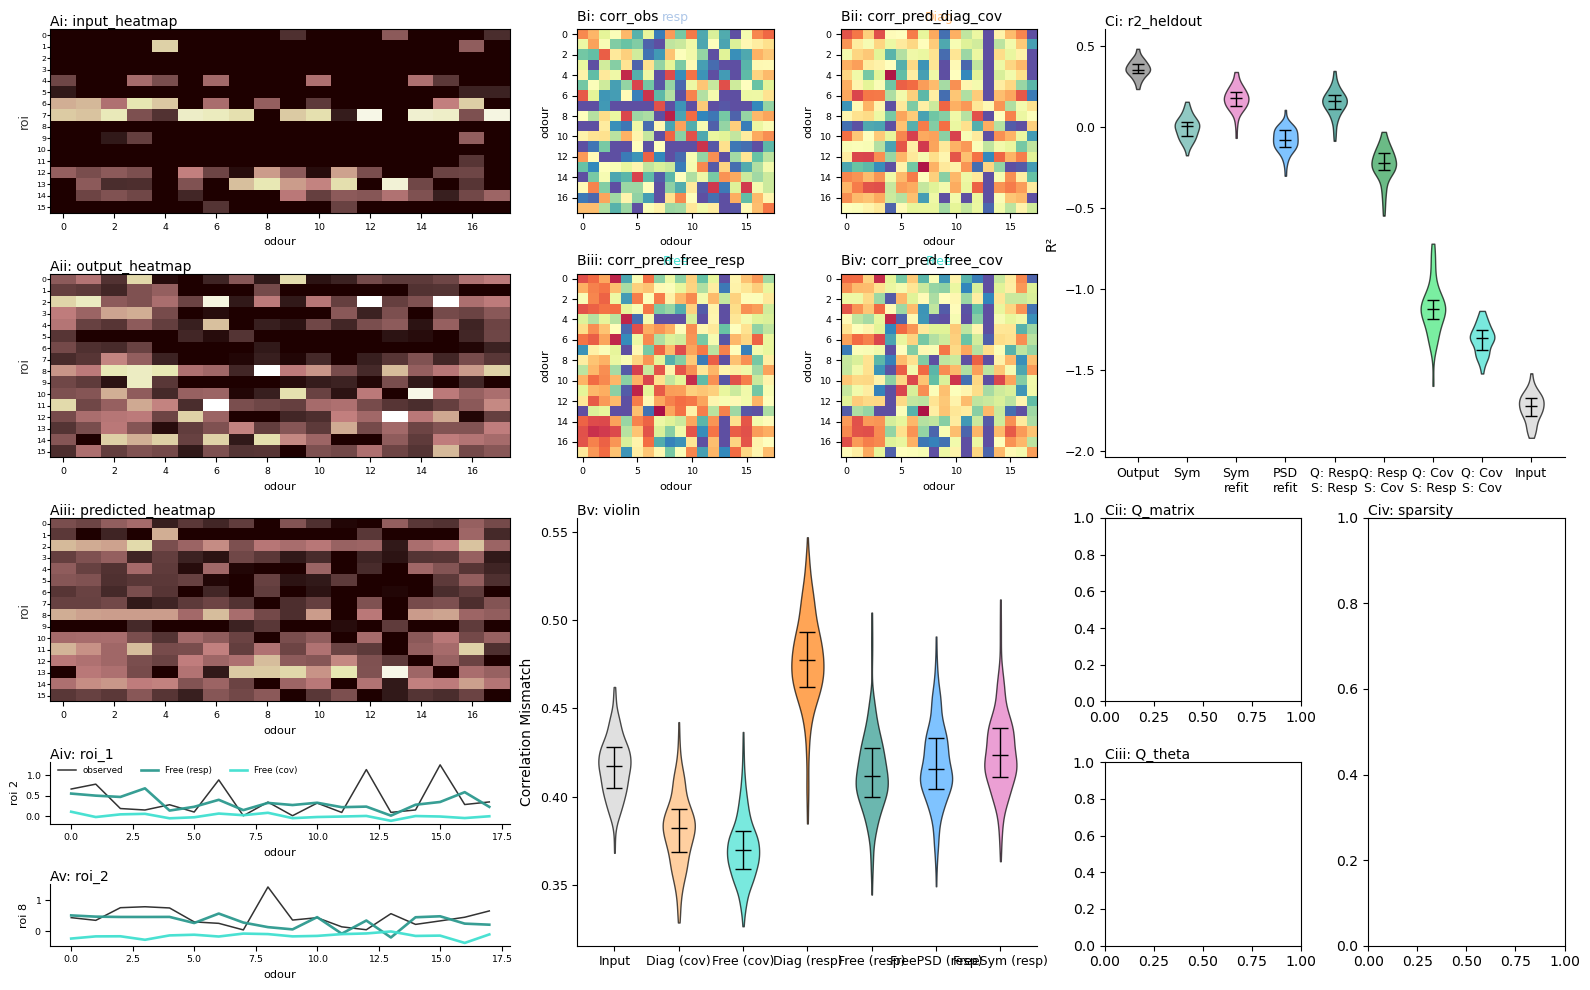

In [62]:
from glom_io_transform.analysis.compute import generalization as compute_generalization; reload(compute_generalization)
from glom_io_transform.model_fitting import proc_fit_models as proc_fit_models; reload(proc_fit_models)
from glom_io_transform.analysis.figures import figures as fig_figures; reload(fig_figures)
from glom_io_transform.analysis.figures import violin_plots as fig_violin_plots; reload(fig_violin_plots)
from glom_io_transform.analysis.figures import matched_rois as fig_matched_rois; reload(fig_matched_rois)

figure(figsize=(16, 10))
fig_matched_rois.Main.plot(matched_rois_data);
tight_layout(w_pad=0.5, h_pad=0.5)

In [ ]:
matched_rois_data.gen_df

,sampler,mode,n_od_train,model,seed,train,outclass,cov_in_out,cov_est_out,corr_in_out,corr_est_out,corr_en_in,corr_en_out,corr_en_est
0,trials,random,18_rand_0,Diag_cov,0,0,None,0.545719,0.290805,0.438619,0.358625,0.418349,0.188585,0.283699
1,trials,random,18_rand_0,Diag_cov,0,1,None,0.528135,0.265813,0.447824,0.363103,0.418349,0.184533,0.283699
2,trials,random,18_rand_0,Diag_cov,0,2,None,0.565479,0.302809,0.447741,0.358831,0.418349,0.161673,0.283699
3,trials,random,18_rand_0,Diag_cov,0,3,None,0.521362,0.255038,0.421949,0.348096,0.418349,0.175164,0.283699
4,trials,random,18_rand_0,Diag_cov,0,4,None,0.552446,0.290418,0.430529,0.342273,0.418349,0.188114,0.283699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,trials,random,18_rand_0,Free_resp,49,5,None,0.531674,0.238953,0.447229,0.394854,0.398502,0.161582,0.355962
996,trials,random,18_rand_0,Free_resp,49,6,None,0.564338,0.335507,0.432472,0.392957,0.398502,0.167293,0.355962
997,trials,random,18_rand_0,Free_resp,49,7,None,0.526307,0.255426,0.429449,0.389139,0.398502,0.174809,0.355962
998,trials,random,18_rand_0,Free_resp,49,8,None,0.526460,0.273125,0.433351,0.389861,0.398502,0.177897,0.355962


## Plot Supplementary Panel

PLOTTING FIGURE matched_rois (metric='resp')
  sign-aligned rois (covariance fits cannot see channel sign): Diag 8/16, Free 8/16
PLOTTING FIGURE matched_rois (metric='cov')
PLOTTING FIGURE matched_rois (metric='corr')


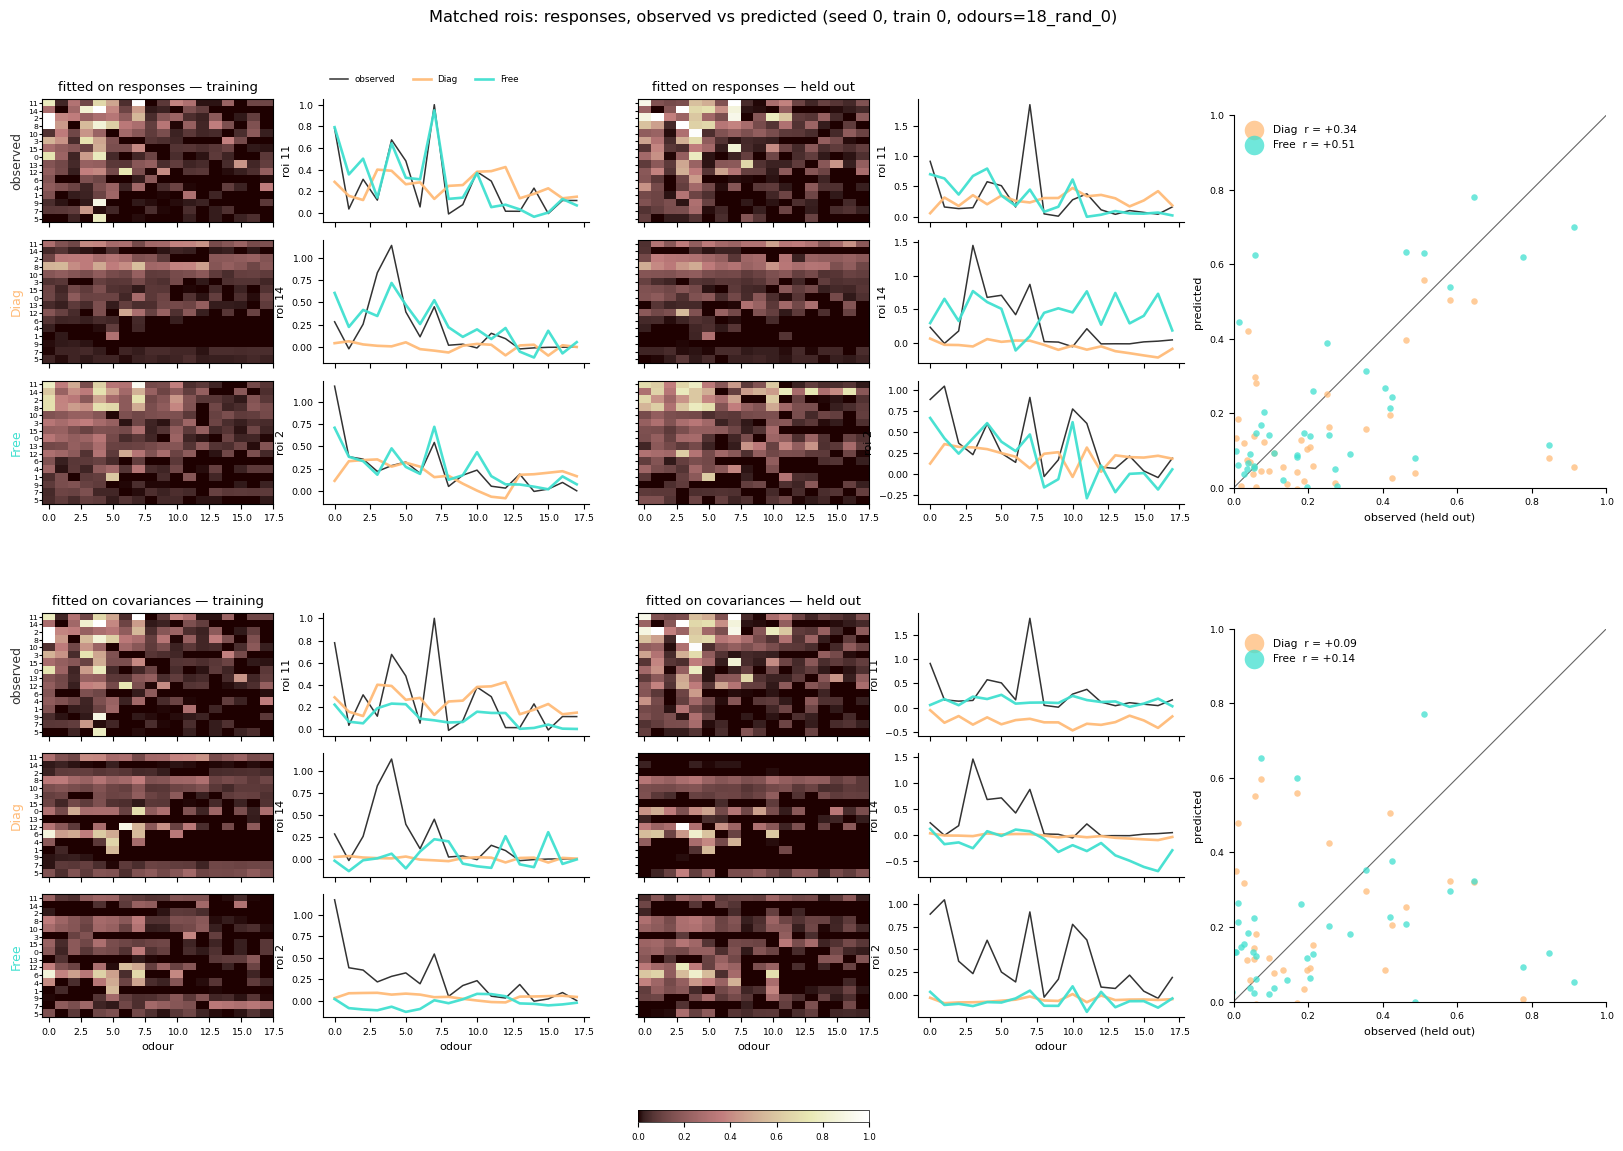

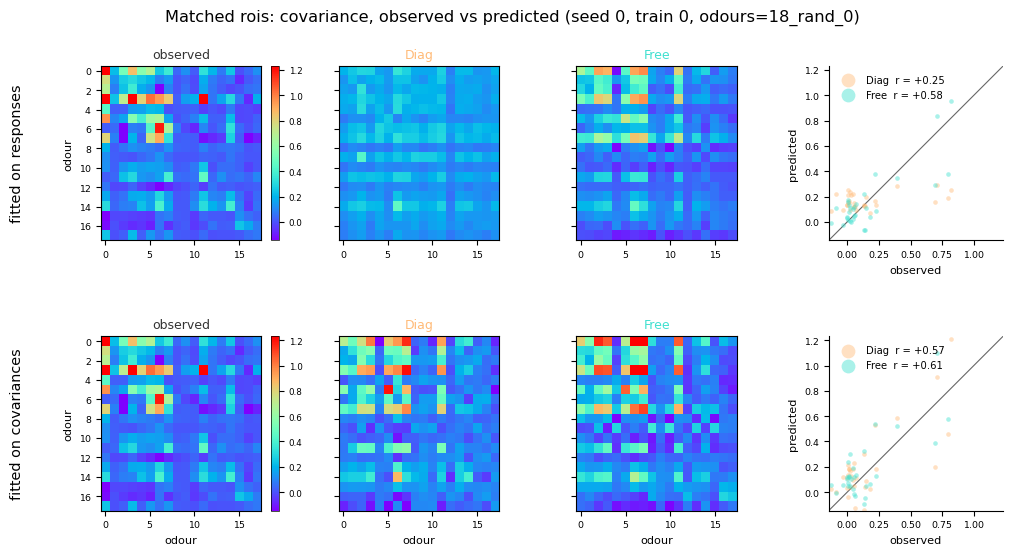

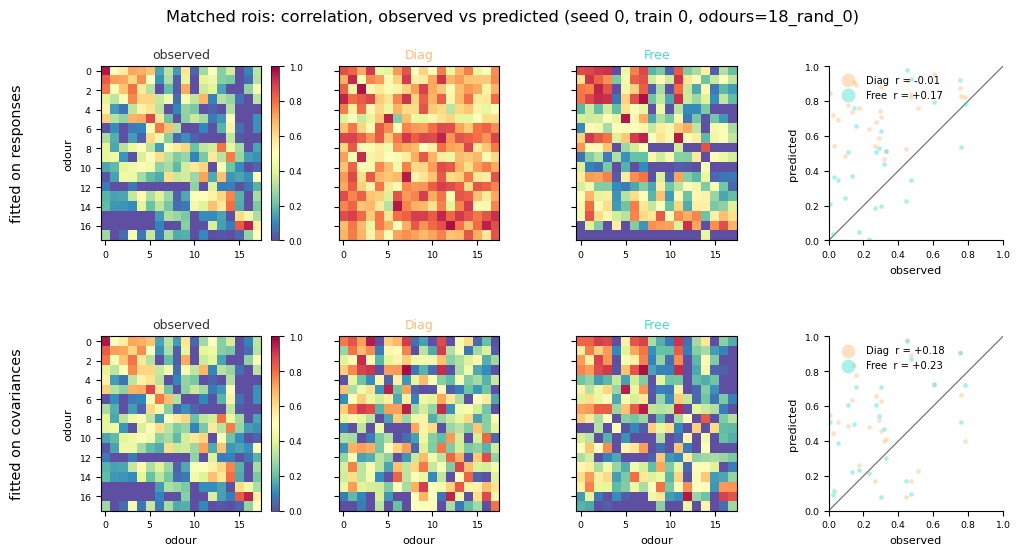

In [ ]:

for metric in ["resp", "cov", "corr"]:
    fig_matched_rois.Supp.plot(matched_rois_data, metric=metric)